# Defender xPoints breakdown

Standalone notebook: top 10 defenders by expected points, split by the point-type each xPoints comes from (goals, assists, clean sheets, defensive contribution).

Run jupyter from the repo root so `import fpl_v2` resolves (`uv run jupyter lab`).

In [1]:
# Ensure the repo root (the dir containing fpl_v2/) is importable, whatever the launch dir.
import sys, pathlib
root = pathlib.Path.cwd()
while not (root / 'fpl_v2').is_dir() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

In [2]:
import plotly.graph_objects as go

from fpl_v2 import pipeline

In [3]:
forecast = pipeline.build_forecast()  # cached data; pipeline.build_forecast(refresh=True) to re-pull live

defenders = forecast[forecast['position'] == 'DEF'].sort_values('xPoints', ascending=False).head(10)
defenders[['web_name', 'team_name', 'xG', 'xAG', 'xClean', 'expected_defcon_points', 'xPoints']]

,web_name,team_name,xG,xAG,xClean,expected_defcon_points,xPoints
373,Senesi,Spurs,1.53,4.72,8.799469,45.847120,103.026483
0,Gabriel,Arsenal,2.94,1.75,15.890859,25.740922,99.741872
241,Virgil,Liverpool,3.77,1.44,9.206913,33.988759,97.756410
180,Tarkowski,Everton,2.53,2.10,7.837359,41.601834,93.606286
371,Van Hecke,Spurs,3.31,1.57,8.799469,34.828128,92.434733
271,Guéhi,Man City,4.05,2.37,11.180432,19.341800,91.942866
154,Lacroix,Crystal Palace,2.45,0.83,7.824994,43.652061,89.076105
325,Thiaw,Newcastle,4.80,0.96,8.410057,26.034137,86.859165
270,O'Reilly,Man City,6.12,2.67,11.180432,4.371557,83.662822
1,J.Timber,Arsenal,4.71,1.53,15.890859,2.743052,81.165435


## Chart

`xpoints.breakdown` (folded into `pipeline.build_forecast`) splits `xPoints` into `goal_points`, `assist_points`, `clean_points` and `defcon_points`, which sum back to `xPoints`.

In [4]:
# Component -> (column, legend label, categorical color).
# Colors are the first four slots of the validated categorical palette (fixed order, never cycled).
COMPONENTS = [
    ('goal_points', 'Goals', '#2a78d6'),
    ('assist_points', 'Assists', '#eb6834'),
    ('clean_points', 'Clean sheets', '#1baf7a'),
    ('defcon_points', 'Defensive contribution', '#eda100'),
]

SURFACE = '#fcfcfb'
GRIDLINE = '#e1e0d9'
AXIS = '#c3c2b7'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'

# Horizontal stacked bars plot bottom-to-top in row order, so sort ascending
# to put the highest total at the top.
plot_df = defenders.sort_values('xPoints', ascending=True).reset_index(drop=True)

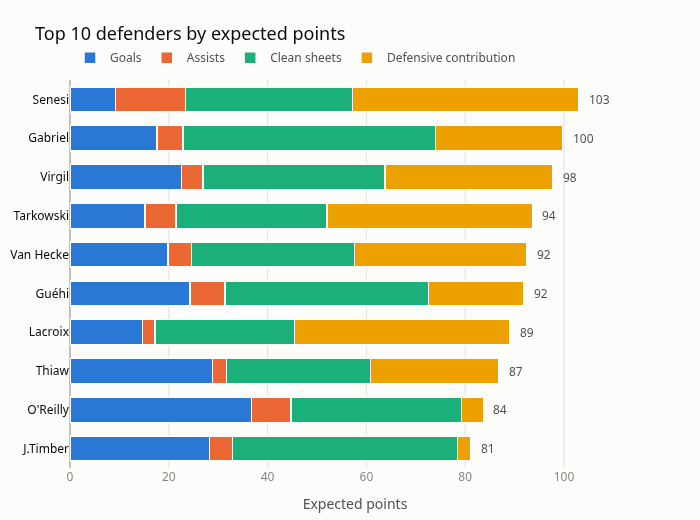

In [5]:
fig = go.Figure()
for col, label, color in COMPONENTS:
    fig.add_trace(go.Bar(
        y=plot_df['web_name'],
        x=plot_df[col],
        name=label,
        orientation='h',
        marker=dict(color=color, line=dict(color=SURFACE, width=1.5)),
        hovertemplate=f'%{{y}}<br>{label}: %{{x:.1f}} pts<extra></extra>',
    ))

# Direct label: total at the bar tip. Per-segment values are left to the
# legend + hover tooltip rather than labelling every stack.
for name, total in zip(plot_df['web_name'], plot_df['xPoints']):
    fig.add_annotation(
        x=total, y=name, text=f'{total:.0f}', showarrow=False,
        xanchor='left', xshift=8, font=dict(color=INK_SECONDARY, size=12),
    )

fig.update_layout(
    barmode='stack',
    bargap=0.35,
    title=dict(text='Top 10 defenders by expected points', font=dict(color=INK_PRIMARY, size=18)),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0,
                traceorder='normal', font=dict(color=INK_SECONDARY)),
    plot_bgcolor=SURFACE,
    paper_bgcolor=SURFACE,
    font=dict(family='system-ui, -apple-system, "Segoe UI", sans-serif', color=INK_SECONDARY),
    xaxis=dict(title='Expected points', gridcolor=GRIDLINE, zerolinecolor=AXIS,
               tickfont=dict(color=INK_MUTED), range=[0, plot_df['xPoints'].max() * 1.12]),
    yaxis=dict(tickfont=dict(color=INK_PRIMARY), automargin=True),
    margin=dict(l=10, r=60, t=80, b=40),
    height=520,
)
fig.show(renderer="png")

## Table view
Same data as the chart, for anyone who wants exact figures rather than reading bar lengths.

In [6]:
cols = ['web_name', 'team_name'] + [c for c, _, _ in COMPONENTS] + ['xPoints']
defenders.sort_values('xPoints', ascending=False)[cols].round(1)

,web_name,team_name,goal_points,assist_points,clean_points,defcon_points,xPoints
373,Senesi,Spurs,9.2,14.2,33.8,45.8,103.0
0,Gabriel,Arsenal,17.6,5.2,51.1,25.7,99.7
241,Virgil,Liverpool,22.6,4.3,36.8,34.0,97.8
180,Tarkowski,Everton,15.2,6.3,30.5,41.6,93.6
371,Van Hecke,Spurs,19.9,4.7,33.0,34.8,92.4
271,Guéhi,Man City,24.3,7.1,41.2,19.3,91.9
154,Lacroix,Crystal Palace,14.7,2.5,28.2,43.7,89.1
325,Thiaw,Newcastle,28.8,2.9,29.1,26.0,86.9
270,O'Reilly,Man City,36.7,8.0,34.6,4.4,83.7
1,J.Timber,Arsenal,28.3,4.6,45.6,2.7,81.2
